## 🎧 Introduction


Welcome to this hands-on lab on **Audio Classification using Deep Learning**.

You'll use the [UrbanSound8K dataset](https://urbansounddataset.weebly.com/urbansound8k.html) to classify sounds from urban environments.

- 0 = air_conditioner
- 1 = car_horn
- 2 = children_playing
- 3 = dog_bark
- 4 = drilling
- 5 = engine_idling
- 6 = gun_shot
- 7 = jackhammer
- 8 = siren
- 9 = street_music

We will go through each step required to:
- Prepare and load audio data
- Build a PyTorch Dataset
- Transform waveforms into log-mel spectrograms
- Train a CNN to classify sounds into 10 classes


In [1]:
import torch
import torchaudio
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler
import torch.optim as optim
from torchsummary import summary
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import pdb
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

## Define the arguments needed to instantiate the MyCustomDataset class and Open Metadata


We begin by loading the `UrbanSound8K.csv` metadata file. This file contains the filename, label, and which fold (subfolder) the file is stored in.

Use matplotlib to represent all the different labels. Comments


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Annotations file is the path to the UrbanSound8K.csv file

Audio Directory is the path to the folder containaing the 10 folds of audio files

We will be using the log-mel spectrogram transformation of torchaudio

Sample rate is 22050 and Number of samples is also 22050

Device is either GPU (mps for Apple and CUDA for Windows) or CPU

---



In [3]:
ANNOTATIONS_FILE = '/content/drive/MyDrive/UrbanSound8K/metadata/UrbanSound8K.csv'
AUDIO_DIR = '/content/drive/MyDrive/UrbanSound8K/audio'
SAMPLE_RATE = 22050
NUM_SAMPLES = 22050

if torch.backends.mps.is_available():
    device = "mps"  # Mac
elif torch.cuda.is_available():
    device = "cuda"  # NVIDIA GPU
else:
    device = "cpu"   # Default to CP

# For windows users if torch.cuda.is_available(): device ="cuda" else: device="cpu"
print(f"We are using {device} device")

We are using cuda device


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(ANNOTATIONS_FILE)

# Preview the first few rows
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


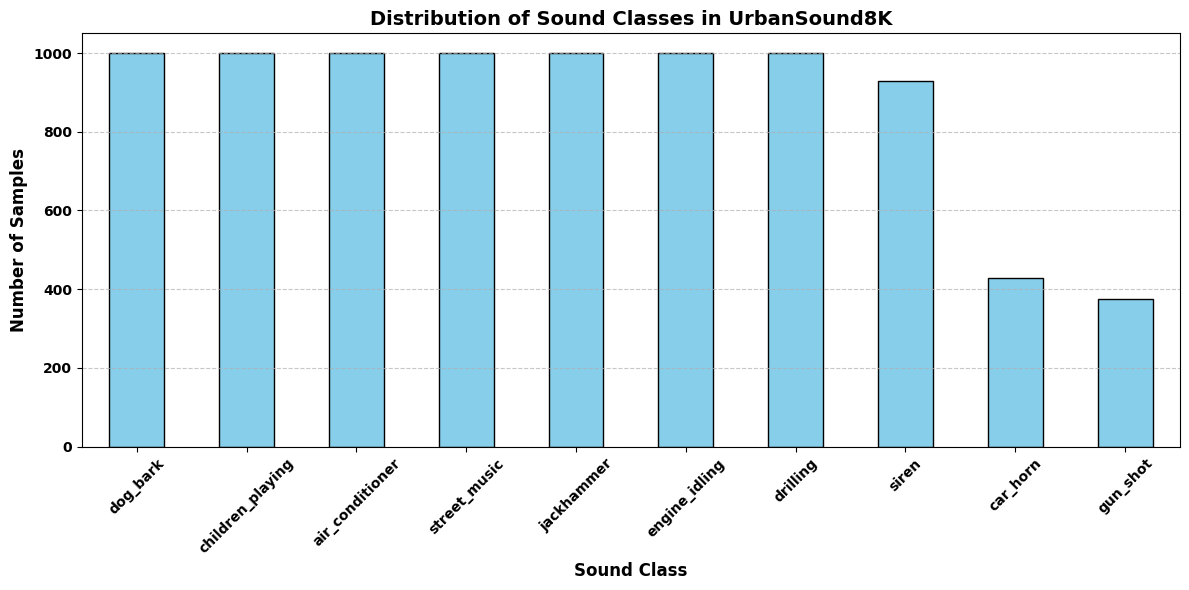

In [5]:
label_counts = df['class'].value_counts()

plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of Sound Classes in UrbanSound8K', fontweight='bold', fontsize=14)
plt.xlabel('Sound Class', fontweight='bold', fontsize=12)
plt.ylabel('Number of Samples', fontweight='bold', fontsize=12)

plt.xticks(rotation=45, fontweight='bold')
plt.yticks(fontweight='bold')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 🎛 Define Transforms (torchaudio)


We use torchaudio to define our transformation pipeline:
- Convert waveform into Mel Spectrogram
- Convert amplitude to decibels

These features work better with CNNs than raw audio waveforms.


In [5]:
mel_spect = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=512,
    n_mels=64
)

log_mel_spect = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80)

transform = nn.Sequential(
    mel_spect,
    log_mel_spect
)




## 🧱 Audio Utility Class


We use a utility class: class AudioUtil

Create different function to

- resample
- pad
- rechannel (all in mono)

These steps ensure that all audio inputs are consistent in format and size.


In [6]:
class AudioUtil:
    def open(self, audio_file):
        sig, sr = torchaudio.load(audio_file)
        return (sig, sr)

    def rechannel(self, aud, new_channel=1):
        sig, sr = aud
        # Already mono
        if sig.shape[0] == new_channel:
            return (sig, sr)

        if new_channel == 1:
            # Convert to mono by averaging across channels
            resig = torch.mean(sig, dim=0, keepdim=True)

        return (resig, sr)

    def resample(self, aud, newsr):
        sig, sr = aud
        if sr == newsr:
            return aud
        num_channels = sig.shape[0]
        resig = torchaudio.transforms.Resample(sr, newsr)(sig[:1,:])
        if num_channels > 1:
            retwo = torchaudio.transforms.Resample(sr, newsr)(sig[1:,:])
            resig = torch.cat([resig, retwo])
        return ((resig, newsr))

    def pad_trunc(self, aud, max_ms):
        sig, sr = aud
        num_rows, sig_len = sig.shape
        max_len = sr//1000 * max_ms
        if sig_len > max_len:
            sig = sig[:, :max_len]
        elif sig_len < max_len:
            pad_begin_len = torch.randint(0, max_len - sig_len, (1,)).item()
            pad_end_len = max_len - sig_len - pad_begin_len
            sig = torch.cat([torch.zeros((num_rows, pad_begin_len)), sig, torch.zeros((num_rows, pad_end_len))], dim=1)
        return (sig, sr)

    def spectro_gram(self, aud):
        sig, sr = aud
        return transform(sig)

        return spec


## 🧩 Custom Dataset (MyCustomDataset)


We now define a custom Dataset class to:
- Load `.wav` files
- Apply transforms
- Return (tensor, label)

This is memory-efficient and PyTorch-compatible.


In [8]:
class MyCustomDataset(Dataset):
    def __init__(self, annotation_file, audio_dir, transform, target_sample_rate, num_samples, device):
        self.annotations = pd.read_csv(annotation_file)
        self.audio_dir = audio_dir
        self.device = device
        self.transform = transform
        self.target_sample_rate = target_sample_rate
        self.num_samples = num_samples
        self.util = AudioUtil()

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        fold = f"fold{self.annotations.iloc[index, 5]}"
        file_name = self.annotations.iloc[index, 0]
        label = self.annotations.iloc[index, 6]
        audio_path = os.path.join(self.audio_dir, "fold" + str(self.annotations.iloc[index, 5]), self.annotations.iloc[index, 0])
        label = self.annotations.iloc[index, 6]
        signal, sr = self.util.open(audio_path)
        #processing
        signal, sr = self.util.resample((signal, sr), self.target_sample_rate)
        signal, sr = self.util.rechannel((signal, sr), 1)
        signal, sr = self.util.pad_trunc((signal, sr), 4000)


        # Transform to spectrogram
        spec = self.transform(signal)

        return spec, label



### Split the dataset into training (80%), validation(10%), and test (10%) dataset
##### Use the random_split from torch.utils.data



In [9]:
full_dataset = MyCustomDataset(
    annotation_file=ANNOTATIONS_FILE,
    audio_dir=AUDIO_DIR,
    transform=transform,
    target_sample_rate=SAMPLE_RATE,
    num_samples=NUM_SAMPLES,
    device=device
)
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

## 🔍 Explore Dataset & Visualize


Now that we have a working dataset, let’s:
- Print the number of samples
- Retrieve the first and last samples
- Plot their log-Mel spectrograms


Number of samples in train_dataset: 6985
First label: 3
Last label: 7


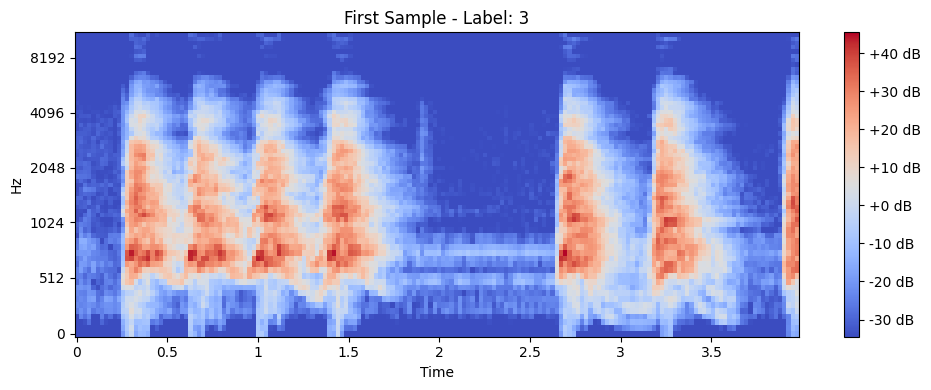

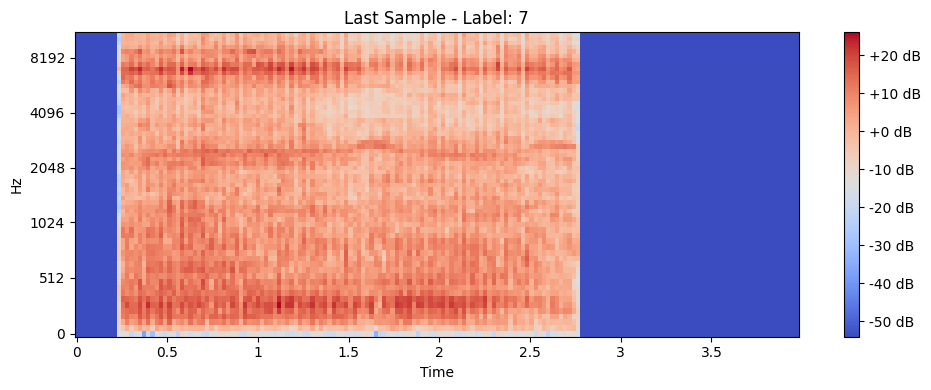

In [10]:
# Print number of samples
print("Number of samples in train_dataset:", len(train_dataset))

# Retrieve first and last sample
first_spec, first_label = train_dataset[0]
last_spec, last_label = train_dataset[len(train_dataset) - 1]

print("First label:", first_label)
print("Last label:", last_label)


# Convert spectrograms from tensor to numpy
first_spec_np = first_spec.squeeze(0).cpu().numpy()
last_spec_np = last_spec.squeeze(0).cpu().numpy()
# Plot log-Mel spectrograms (first and last)

# First sample plot
plt.figure(figsize=(10, 4))
librosa.display.specshow(first_spec_np, sr=SAMPLE_RATE, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"First Sample - Label: {first_label}")
plt.tight_layout()
plt.show()

# Last sample plot
plt.figure(figsize=(10, 4))
librosa.display.specshow(last_spec_np, sr=SAMPLE_RATE, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Last Sample - Label: {last_label}")
plt.tight_layout()
plt.show()





## Dataloaders


### Create a train, validation and test dataloaders using dataloaders from torch.utils.data
##### Use a batch size of 64
##### Remember to turn on shuffle for training and turn it off for validation and testing


In [11]:
BATCH_SIZE = 64

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## 🧠 Define CNN Model


The model structure will be unique for every student

The model should consist of convolutions, pooling, batch normalization, flatten, activation functions and linear layers

Recall that there are 10 classes in the dataset, hence the final layer will have 10 neurons


In [27]:

class AudioClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5, padding=2),   # [B, 8, 64, 173]
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.MaxPool2d(2),                             # [B, 8, 32, 86]
            nn.Dropout(0.1),                             # léger dropout après maxpool

            nn.Conv2d(8, 16, kernel_size=3, padding=1),  # [B, 16, 32, 86]
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2),                             # [B, 16, 16, 43]
            nn.Dropout(0.15),                            # un peu plus ici

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # [B, 32, 16, 43]
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),                             # [B, 32, 8, 21]
            nn.Dropout(0.2),                             # plus profond → plus de dropout

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 64, 8, 21]
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.AdaptiveAvgPool2d((1, 1)),                # [B, 64, 1, 1]
            nn.Flatten(),                                # [B, 64]
            nn.Dropout(0.3),                             # juste avant la couche finale

            nn.Linear(64, 10)                            # [B, 10]
        )

    def forward(self, x):
        return self.net(x)


Use the summary fuction in the torchsummary library to print the number of parameters and the estimated size of the model

In [28]:
from torchsummary import summary
model = AudioClassifier().to(device)
summary(model, input_size=(1, 128, 173))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 128, 173]             208
              ReLU-2          [-1, 8, 128, 173]               0
       BatchNorm2d-3          [-1, 8, 128, 173]              16
         MaxPool2d-4            [-1, 8, 64, 86]               0
           Dropout-5            [-1, 8, 64, 86]               0
            Conv2d-6           [-1, 16, 64, 86]           1,168
              ReLU-7           [-1, 16, 64, 86]               0
       BatchNorm2d-8           [-1, 16, 64, 86]              32
         MaxPool2d-9           [-1, 16, 32, 43]               0
          Dropout-10           [-1, 16, 32, 43]               0
           Conv2d-11           [-1, 32, 32, 43]           4,640
             ReLU-12           [-1, 32, 32, 43]               0
      BatchNorm2d-13           [-1, 32, 32, 43]              64
        MaxPool2d-14           [-1, 32,

## Train for 1 Epoch

Create a Training Function for one epoch only

Using a for loop, the train function will take as arguments: the model, train loader, loss function, optimizer, etc

Use the cross-entropy loss function and calculate accuracy


This helps check your model and dataset before full training.


In [29]:

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total, correct, total_loss = 0, 0, 0
    loop = tqdm(loader, desc="Training", leave=False)
    for X, y in loop:
        X, y = X.to(device), y.to(device)
        #normaliaze
        X = (X - X.mean()) / X.std()

        optimizer.zero_grad()
        outputs = model(X)
        loss = loss_fn(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    acc = correct / total
    avg_loss = total_loss / len(loader)

    print(f"Train Accuracy: {acc:.4f} | Loss: {avg_loss:.4f}")
    return avg_loss, acc


### Run it for 1 epoch

In [20]:
model = AudioClassifier().to(device)

# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Scheduler:adjusts the learning rate during training to help converge better or faster
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


# Train for one epoch
#train_one_epoch(model, train_loader, loss_fn, optimizer, device)

## Valid for 1 Epoch

Create a valid Function for one epoch only

##### Using a for loop, the validation function will take as arguments: the model, validation loader, loss function, scheduler
##### It will be wise to include best model parameters are arguments at this point
##### The goal is to monitor the performance of your proposed model to avoid overfitting/underfitting, know the best epoch to save the model weights, etc.

In [30]:
def validate_one_epoch(model, val_loader, loss_fn, scheduler, best_val_loss, best_model_state, device):
    model.eval()
    total, correct, total_loss = 0, 0, 0
    loop = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for X, y in loop:
            X, y = X.to(device), y.to(device)
            X = (X - X.mean()) / X.std()

            outputs = model(X)
            loss = loss_fn(outputs, y)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    acc = correct / total
    avg_loss = total_loss / len(val_loader)

    print(f"Validation Accuracy: {acc:.4f} | Loss: {avg_loss:.4f}")

    # Step the scheduler (only if it's ReduceLROnPlateau)
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(avg_loss)

    # Update best model
    if avg_loss < best_val_loss:
        print("✅ New best model found — saving weights")
        best_val_loss = avg_loss
        best_model_state = model.state_dict()

    return avg_loss, acc, best_val_loss, best_model_state


**IT IS TOO SLOW ON MY COMPUTER!! I will precompute all the melspectro and save them, so I do not do it for each epoch**

In [15]:
def precompute_and_save(annotation_file, audio_dir, output_dir, transform, target_sample_rate, max_ms):
    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(annotation_file)

    util = AudioUtil()

    for idx in tqdm(range(len(df)), desc="Precomputing"):
        row = df.iloc[idx]
        fold = f"fold{row['fold']}"
        file_path = os.path.join(audio_dir, fold, row['slice_file_name'])
        label = row['classID']

        signal, sr = util.open(file_path)
        signal, sr = util.resample((signal, sr), target_sample_rate)
        signal, sr = util.rechannel((signal, sr), 1)
        signal, sr = util.pad_trunc((signal, sr), max_ms)

        spec = transform(signal)

        # Save spectrogram as tensor
        save_path = os.path.join(output_dir, f"{idx:05d}_{label}.pt")
        torch.save({'spec': spec, 'label': label}, save_path)

In [16]:
precompute_and_save(
    annotation_file=ANNOTATIONS_FILE,
    audio_dir=AUDIO_DIR,
    output_dir="/content/drive/MyDrive/UrbanSound8K/precomputed",
    transform=transform,
    target_sample_rate=SAMPLE_RATE,
    max_ms=1000
)

Precomputing: 100%|██████████| 8732/8732 [1:20:45<00:00,  1.80it/s]


In [31]:
class MycustomDataset_prepro(Dataset):
    def __init__(self, spectrogram_dir):
        self.files = sorted([
            os.path.join(spectrogram_dir, f)
            for f in os.listdir(spectrogram_dir) if f.endswith(".pt")
        ])


    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx], weights_only=False, map_location='cpu')

        spec = data['spec'].float()
        label = data['label']
        return spec, label

In [32]:
full_dataset = MycustomDataset_prepro("/content/drive/MyDrive/UrbanSound8K/precomputed")

# Split into train/val/test
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

In [33]:
BATCH_SIZE = 64

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [34]:
model = AudioClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


# Train for one epoch
#train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)


## 🔁 Full Training Loop

### Create a Function that will call the training and validation functions just created
##### This function will interate over all the epochs that you define
##### It will also activate your early stopping, so that the model does not continue training without improvements in the validation


In [35]:

def full_train(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    scheduler,
    device,
    num_epochs=30,
    patience=5
):
    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        print(f"\n🟦 Epoch {epoch + 1}/{num_epochs}")

        # Train
        avg_loss_train, acc_train = train_one_epoch(
            model, train_loader, loss_fn, optimizer, device
        )

        # Validate
        avg_loss_valid, acc_valid, best_val_loss, best_model_state = validate_one_epoch(
            model, val_loader, loss_fn, scheduler,
            best_val_loss, best_model_state,
            device
        )

        # Save metrics
        train_losses.append(avg_loss_train)
        val_losses.append(avg_loss_valid)
        train_accuracies.append(acc_train)
        val_accuracies.append(acc_valid)

        # Print metrics for epoch
        print(f"📊 Epoch {epoch+1} Summary:")
        print(f"   Train Loss: {avg_loss_train:.4f} | Train Acc: {acc_train:.4f}")
        print(f"   Val   Loss: {avg_loss_valid:.4f} | Val   Acc: {acc_valid:.4f}")

        # Early Stopping logic
        if scheduler and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step()

        current_val_loss = avg_loss_valid
        if current_val_loss < best_val_loss:
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            print(f"   🔁 No improvement. Patience counter: {epochs_without_improvement}/{patience}")

        if epochs_without_improvement >= patience:
            print("⛔ Early stopping triggered.")
            break

    print("\n✅ Training complete.")
    return best_model_state, train_losses, val_losses, train_accuracies, val_accuracies


# Now commence training.
### At the point, you will manually revisit the model function to tune the hyperparameters with a goal of improving the results
##### Some of the hyperparameters to be tuned include
###### Learning rate
###### Number of convolution layers
###### Number of channels per layer
###### Number of neurons in the fully connected layer
###### Choice of activation function
###### Type of scheduler
###### Regularizers such as dropouts, L1, or L2 regularizers, etc.


### When you arrive at the most optimal performance, save the model weights at the points


In [37]:
best_model_state, train_losses, val_losses, train_accs, val_accs=full_train(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    scheduler,
    device,
    num_epochs=30,
    patience=20 #if validation loss hasn’t improved for patience epoch, stop
)

torch.save(best_model_state, 'best_model.pth')



🟦 Epoch 1/30


Train Accuracy: 0.6958 | Loss: 0.9040


Validation Accuracy: 0.6838 | Loss: 0.9312
✅ New best model found — saving weights
📊 Epoch 1 Summary:
   Train Loss: 0.9040 | Train Acc: 0.6958
   Val   Loss: 0.9312 | Val   Acc: 0.6838
   🔁 No improvement. Patience counter: 1/20

🟦 Epoch 2/30


Train Accuracy: 0.7099 | Loss: 0.8653


Validation Accuracy: 0.6323 | Loss: 1.0323
📊 Epoch 2 Summary:
   Train Loss: 0.8653 | Train Acc: 0.7099
   Val   Loss: 1.0323 | Val   Acc: 0.6323
   🔁 No improvement. Patience counter: 2/20

🟦 Epoch 3/30


...

Validation Accuracy: 0.8110 | Loss: 0.5783
✅ New best model found — saving weights
📊 Epoch 18 Summary:
   Train Loss: 0.5408 | Train Acc: 0.8209
   Val   Loss: 0.5783 | Val   Acc: 0.8110
   🔁 No improvement. Patience counter: 18/20

🟦 Epoch 19/30


Train Accuracy: 0.8261 | Loss: 0.5269


Validation Accuracy: 0.8110 | Loss: 0.5636
✅ New best model found — saving weights
📊 Epoch 19 Summary:
   Train Loss: 0.5269 | Train Acc: 0.8261
   Val   Loss: 0.5636 | Val   Acc: 0.8110
   🔁 No improvement. Patience counter: 19/20

🟦 Epoch 20/30


Train Accuracy: 0.8199 | Loss: 0.5418


Validation Accuracy: 0.8144 | Loss: 0.5590
✅ New best model found — saving weights
📊 Epoch 20 Summary:
   Train Loss: 0.5418 | Train Acc: 0.8199
   Val   Loss: 0.5590 | Val   Acc: 0.8144
   🔁 No improvement. Patience counter: 20/20
⛔ Early stopping triggered.

✅ Training complete.


### Make a plot of the training and validation losses as well as the accuracies over all the epochs considered

In [38]:
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracies
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label='Train Accuracy')
    plt.plot(epochs, val_accs, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [39]:
model = AudioClassifier().to(device)

# Load the best model weights
model.load_state_dict(torch.load('best_model.pth'))
model.eval()  # set to evaluation model


AudioClassifier(
  (net): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
    (5): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.15, inplace=False)
    (10): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.2, inplace=False)
    (15): Conv2d(32, 64, kernel_size=(3, 3), stride

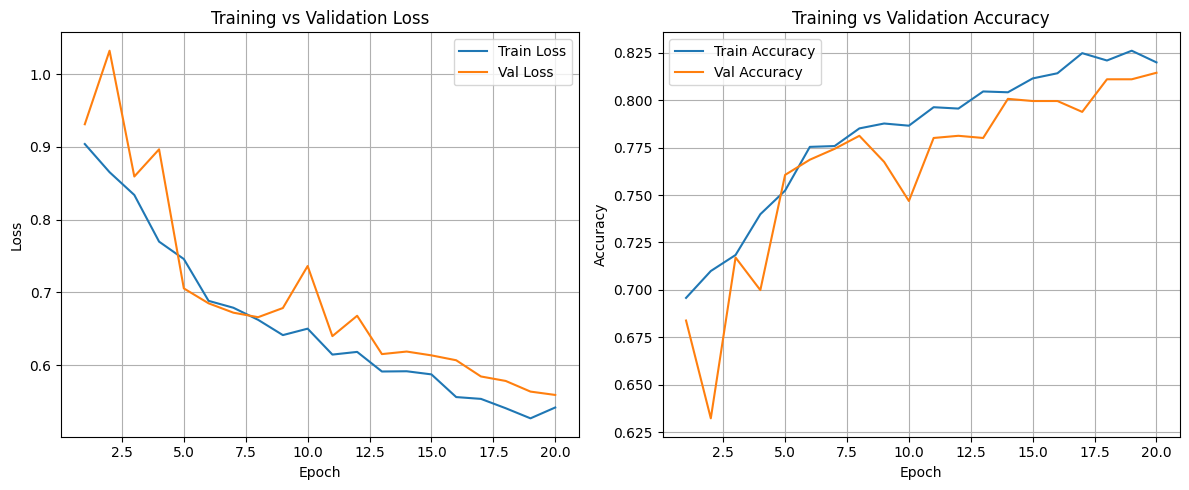

In [40]:
plot_training_curves(train_losses, val_losses, train_accs, val_accs)

### Evaluate ther performance using Confusion Matrix and Classification Report
##### The sklearn library provides functions that can be used to visualize these results
##### Give a detailed explanation of your results. Explain the concepts of accuracy, precision, recall, F1-Score, etc

In [41]:
def get_all_preds_and_labels(model, loader, best_model_state, device):
    model.load_state_dict(best_model_state)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            X = (X - X.mean()) / X.std()
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

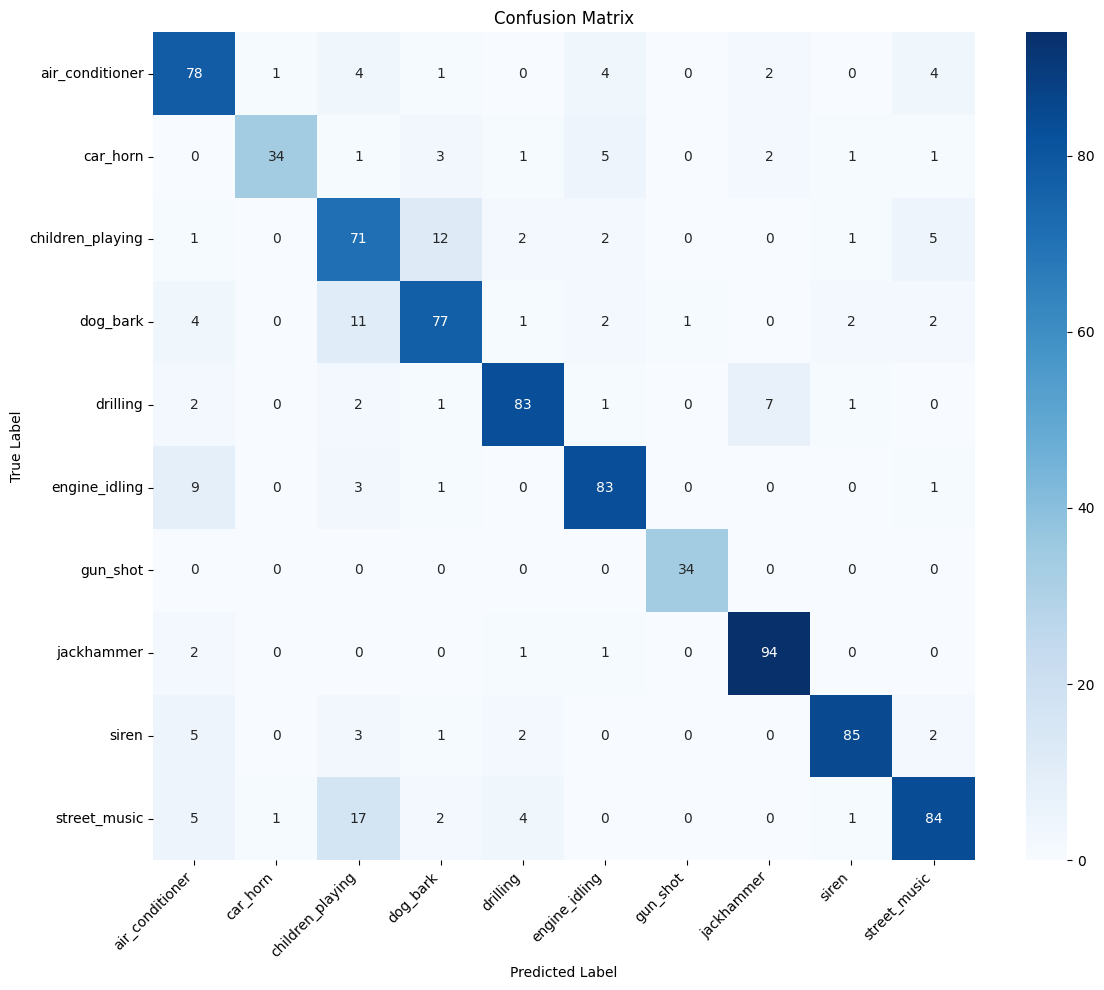

In [42]:
class_names = [
    "air_conditioner", "car_horn", "children_playing", "dog_bark", "drilling",
    "engine_idling", "gun_shot", "jackhammer", "siren", "street_music"
]

import seaborn as sns
y_pred, y_true = get_all_preds_and_labels(model, test_loader, best_model_state, device)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.7358    0.8298    0.7800        94
           1     0.9444    0.7083    0.8095        48
           2     0.6339    0.7553    0.6893        94
           3     0.7857    0.7700    0.7778       100
           4     0.8830    0.8557    0.8691        97
           5     0.8469    0.8557    0.8513        97
           6     0.9714    1.0000    0.9855        34
           7     0.8952    0.9592    0.9261        98
           8     0.9341    0.8673    0.8995        98
           9     0.8485    0.7368    0.7887       114

    accuracy                         0.8272       874
   macro avg     0.8479    0.8338    0.8377       874
weighted avg     0.8347    0.8272    0.8283       874

